# 더 멋진 번역기 만들기 — 최종 프로젝트 완성본

이 노트북은 **PyTorch + SentencePiece + Transformer**를 이용해 한–영 번역기를 직접 구현한 최종 제출용 프로젝트입니다.
데이터 다운로드부터 전처리, 토큰화, 모델 구현, 학습, 검증, Beam Search 추론, Attention Map 시각화까지 전체 과정을 하나의 노트북에 담았습니다.

## 프로젝트 목표

1. 한–영 병렬 말뭉치의 중복을 제거하고 요구 조건에 맞게 정제합니다.
2. SentencePiece로 한국어·영어 토크나이저를 각각 학습합니다.
3. Transformer의 핵심 구성 요소를 PyTorch로 직접 구현합니다.
4. 논문 방식의 Warmup Learning Rate와 Adam Optimizer로 모델을 학습합니다.
5. Greedy Search와 Beam Search를 비교하고, 최종 번역 결과와 Attention Map을 출력합니다.
6. 학습 과정에서 발생할 수 있는 오류를 점검하고 디버깅 과정을 기록합니다.

모델 구조는 Transformer 논문의 기본 구조를 참고하여 Encoder와 Decoder를 각각 2개 Layer로 구성하였다. 또한 Multi-Head Attention, Positional Encoding, Position-wise Feed Forward Network, Residual Connection, Layer Normalization, Padding Mask, Look-ahead Mask 등을 직접 구현하였다.

## 성능 향상을 위해 적용한 요소

- 길이 조건을 만족하는 전체 병렬 데이터 사용
- Encoder/Decoder 각각 2개 Layer
- `d_model=512`, `n_heads=8`, `d_ff=2048`
- Label Smoothing
- Gradient Clipping
- CUDA Mixed Precision
- 검증 데이터 분리 및 최적 체크포인트 저장
- Beam Search와 Length Penalty
- Cross-Attention Map 시각화


## Step 0. 라이브러리 버전 확인 및 GPU 확인

In [1]:
# CUDA 지원 PyTorch가 이미 설치된 환경을 사용합니다.
# torch를 다시 설치하면 CPU 전용 버전으로 바뀔 수 있으므로 재설치하지 않습니다.
%pip install -q sentencepiece numpy matplotlib

import os
import re
import time
import math
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import sentencepiece as spm
import matplotlib.pyplot as plt

# 재현 가능한 실험을 위한 난수 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 CUDA를 사용하고, 없으면 오류를 발생시켜
# 긴 학습이 실수로 CPU에서 실행되는 것을 방지합니다.
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU를 사용할 수 없습니다. "
        "Jupyter 커널과 CUDA용 PyTorch 설치 상태를 확인해 주세요."
    )

device = torch.device("cuda:0")
# Tesla T4 GPU는 그대로 사용하지만, 수치 불안정으로 인한 NaN을 방지하기 위해
# 이번 최종본에서는 Mixed Precision을 끕니다.
# FP32 학습은 조금 느리지만 번역 품질과 학습 안정성이 더 중요합니다.
USE_AMP = False

torch.cuda.set_device(0)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("사용 장치:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Mixed Precision:", USE_AMP)


PyTorch: 2.11.0+cu128
CUDA 사용 가능: True
사용 장치: cuda:0
GPU: Tesla T4
Mixed Precision: False


## Step 1. 데이터 다운로드 (로컬 유저용)

[jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora)의
`korean-english-park.train.tar.gz`를 다운로드하여 한영 병렬 데이터를 확보합니다.

원본 실습은 터미널에서 `wget` / `tar`를 사용하지만, 여기서는 동일한 동작을
Python(`urllib.request`, `tarfile`)으로 재현합니다.

In [2]:
DATA_DIR = Path(os.getcwd()) / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

TAR_URL = (
    "https://github.com/jungyeul/korean-parallel-corpora/raw/master/"
    "korean-english-news-v1/korean-english-park.train.tar.gz"
)
TAR_PATH = DATA_DIR / "korean-english-park.train.tar.gz"
KO_PATH = DATA_DIR / "korean-english-park.train.ko"
EN_PATH = DATA_DIR / "korean-english-park.train.en"

if not TAR_PATH.exists():
    print("korean-english-park.train.tar.gz 다운로드 중...")
    urllib.request.urlretrieve(TAR_URL, TAR_PATH)
    print("다운로드 완료:", TAR_PATH)
else:
    print("이미 다운로드된 파일이 있습니다:", TAR_PATH)

if not (KO_PATH.exists() and EN_PATH.exists()):
    print("압축 해제 중...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        # 경로 탈출(path traversal)을 방지하며 압축을 해제합니다.
        base = DATA_DIR.resolve()
        for member in tar.getmembers():
            target = (DATA_DIR / member.name).resolve()
            if base not in target.parents and target != base:
                raise RuntimeError(f"안전하지 않은 압축 경로입니다: {member.name}")
        tar.extractall(path=DATA_DIR)
    print("압축 해제 완료")
else:
    print("이미 압축 해제된 파일이 있습니다.")

print(sorted(os.listdir(DATA_DIR)))


korean-english-park.train.tar.gz 다운로드 중...
다운로드 완료: /content/data/korean-english-park.train.tar.gz
압축 해제 중...


/tmp/ipykernel_477/3342428036.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


압축 해제 완료
['korean-english-park.train.en', 'korean-english-park.train.ko', 'korean-english-park.train.tar.gz']


In [3]:
with open(KO_PATH, encoding="utf-8") as f:
    raw_kor = f.read().splitlines()

with open(EN_PATH, encoding="utf-8") as f:
    raw_eng = f.read().splitlines()

assert len(raw_kor) == len(raw_eng), "한/영 문장 수가 일치하지 않습니다."
print("전체 문장 쌍 개수:", len(raw_kor))
print("예시 한국어:", raw_kor[0])
print("예시 영어  :", raw_eng[0])


전체 문장 쌍 개수: 94123
예시 한국어: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
예시 영어  : Much of personal computing is about "can you top this?"


## Step 2. 데이터 정제 및 토큰화

### 1) 중복 제거

한국어 문장과 영어 문장을 각각 별도로 `set`으로 변환할 경우 문장의 순서가 달라져 서로 다른 문장이 하나의 번역 쌍으로 연결될 수 있다.

따라서 본 프로젝트에서는 다음과 같이 한국어와 영어 문장을 하나의 튜플로 묶은 상태에서 중복을 제거하였다.

또한 `seen_pairs` 를 이용하여 원본 순서를 최대한 유지하였다. 이를 통해 중복 문장을 제거하면서도 한국어-영어 번역 쌍의 대응 관계가 흐트러지지 않도록 하였다

In [4]:
# set을 이용해 중복 여부를 검사하되, 원본 순서를 유지합니다.
# 한국어와 영어를 각각 중복 제거하면 병렬 쌍이 깨지므로 반드시 튜플 단위로 처리합니다.
# 이미 확인한 (한국어, 영어) 문장 쌍을 저장하는 집합입니다.
# 개별 언어 문장을 따로 set으로 만들면 병렬 관계가 깨질 수 있으므로 반드시 튜플 단위로 처리합니다.
seen_pairs = set()
cleaned_corpus = []

for pair in zip(raw_kor, raw_eng):
    if pair not in seen_pairs:
        seen_pairs.add(pair)
        cleaned_corpus.append(pair)

print("중복 제거 전:", len(raw_kor))
print("중복 제거 후:", len(cleaned_corpus))
print("제거된 중복:", len(raw_kor) - len(cleaned_corpus))


중복 제거 전: 94123
중복 제거 후: 78968
제거된 중복: 15155


### 2) 정제 함수

한국어와 영어 문장에 동일한 정제 규칙을 적용하였다.

정제 과정은 다음과 같다.

- 모든 영문자를 소문자로 변환
- 한글, 영문 알파벳, 문장부호만 유지
- 불필요한 숫자와 특수문자 제거
- 문장부호 앞뒤에 공백 추가
- 연속된 공백을 하나로 정리
- 문장 앞뒤 공백 제거

이 과정을 통해 토크나이저가 불필요한 문자 패턴을 학습하지 않도록 하였다.

In [5]:
def preprocess_sentence(sentence):
    # 1. 소문자 변환 및 양끝 공백 제거
    sentence = sentence.lower().strip()

    # 2. 주요 문장부호 양옆에 공백 추가
    # 영어 축약형(don't 등)을 보존하기 위해 apostrophe(')는 제거하지 않습니다.
    sentence = re.sub(r'([?.!,¿"])', r" \1 ", sentence)

    # 3. 알파벳, 한글, 문장부호만 남기기
    sentence = re.sub(r'''[^a-zA-Z가-힣ㄱ-ㅎㅏ-ㅣ?.!,¿"'']+''', " ", sentence)

    # 4. 연속 공백을 하나로 만들고 양끝 공백 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

print(preprocess_sentence("오바마는 대통령이다."))
print(preprocess_sentence("He is the President of the U.S.!"))
print(preprocess_sentence("I don't need coffee."))


오바마는 대통령이다 .
he is the president of the u . s . !
i don't need coffee .


### 3) 한/영 말뭉치 분리 및 SentencePiece 토크나이저 학습

한글 말뭉치 `kor_corpus`와 영문 말뭉치 `eng_corpus`를 정제한 뒤, `generate_tokenizer()`로
SentencePiece 모델을 학습합니다. 특수 토큰은 `<PAD>:0 / <BOS>:1 / <EOS>:2 / <UNK>:3` 로 고정합니다.
`en_tokenizer`에는 `set_encode_extra_options("bos:eos")`를 적용해 인코딩 시 문장 시작/끝 토큰이
자동으로 붙게 합니다.

In [6]:
kor_corpus = []
eng_corpus = []

for kor, eng in cleaned_corpus:
    kor_clean = preprocess_sentence(kor)
    eng_clean = preprocess_sentence(eng)

    # 정제 후 빈 문장이 된 쌍은 제외합니다.
    if kor_clean and eng_clean:
        kor_corpus.append(kor_clean)
        eng_corpus.append(eng_clean)

assert len(kor_corpus) == len(eng_corpus)

print("정제된 병렬 문장 수:", len(kor_corpus))
print("한국어 예시:", kor_corpus[0])
print("영어   예시:", eng_corpus[0])


정제된 병렬 문장 수: 78963
한국어 예시: 개인용 컴퓨터 사용의 상당 부분은 " 이것보다 뛰어날 수 있느냐 ? "
영어   예시: much of personal computing is about " can you top this ? "


In [7]:
def generate_tokenizer(
    corpus,
    vocab_size=16000,
    lang="ko",
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    force_retrain=False,
    max_training_sentences=100000,
):
    """
    SentencePiece BPE 토크나이저를 생성하거나 기존 모델을 불러옵니다.

    핵심 최적화
    1. 저장된 모델이 있으면 코퍼스 파일도 다시 만들지 않고 즉시 로드합니다.
    2. 최초 학습 시 최대 100,000문장만 무작위로 사용하여 시간을 단축합니다.
    3. 어휘 크기 16,000으로 품질과 학습 시간의 균형을 맞춥니다.

    SentencePiece 학습은 CPU에서 수행되며,
    이후 Transformer 모델 학습은 CUDA GPU에서 수행됩니다.
    """
    model_dir = DATA_DIR / "spm"
    model_dir.mkdir(parents=True, exist_ok=True)

    # 어휘 크기를 파일명에 포함하여 서로 다른 vocab 모델이 섞이지 않게 합니다.
    model_prefix = model_dir / f"spm_{lang}_{vocab_size}"
    model_path = Path(f"{model_prefix}.model")
    corpus_path = model_dir / f"corpus_{lang}.txt"

    # 기존 모델이 있으면 코퍼스 재작성과 재학습을 모두 건너뜁니다.
    if model_path.exists() and not force_retrain:
        tokenizer = spm.SentencePieceProcessor()
        tokenizer.load(str(model_path))
        print(f"[{lang}] 기존 토크나이저 로드: {model_path.name}")
        return tokenizer

    # 실제로 새 토크나이저를 학습할 때만 텍스트 파일을 생성합니다.
    print(f"[{lang}] 코퍼스 파일 작성 시작")
    with open(corpus_path, "w", encoding="utf-8") as f:
        for line in corpus:
            f.write(line + "\n")

    # 전체 문장 수보다 큰 값을 지정해도 문제가 없도록 안전하게 조정합니다.
    input_sentence_size = min(len(corpus), max_training_sentences)

    print(
        f"[{lang}] SentencePiece 학습 시작 "
        f"(사용 문장: {input_sentence_size:,}, vocab: {vocab_size:,})"
    )
    start_time = time.time()

    spm.SentencePieceTrainer.train(
        input=str(corpus_path),
        model_prefix=str(model_prefix),
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=1.0,
        pad_id=pad_id,
        bos_id=bos_id,
        eos_id=eos_id,
        unk_id=unk_id,
        pad_piece="<PAD>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
        unk_piece="<UNK>",
        hard_vocab_limit=False,
        input_sentence_size=input_sentence_size,
        shuffle_input_sentence=True,
        max_sentence_length=4096,
        minloglevel=1,
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.load(str(model_path))

    elapsed = time.time() - start_time
    print(f"[{lang}] SentencePiece 학습 완료: {elapsed:.1f}초")
    return tokenizer


# 과제 기본값인 20,000으로 설정해 서브워드 분절을 줄이고 번역 품질을 높입니다.
VOCAB_SIZE = 20000

# 최초 한 번만 True로 두면 새 토크나이저를 만들고,
# 이후에는 False 상태에서 저장된 모델을 즉시 불러옵니다.
FORCE_RETRAIN_TOKENIZER = False

ko_tokenizer = generate_tokenizer(
    kor_corpus,
    vocab_size=VOCAB_SIZE,
    lang="ko",
    force_retrain=FORCE_RETRAIN_TOKENIZER,
)

en_tokenizer = generate_tokenizer(
    eng_corpus,
    vocab_size=VOCAB_SIZE,
    lang="en",
    force_retrain=FORCE_RETRAIN_TOKENIZER,
)

# 영어 타깃 문장에 문장 시작/종료 토큰을 자동으로 추가합니다.
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3

# 과제에서 지정한 특수 토큰 인덱스를 검증합니다.
assert ko_tokenizer.pad_id() == PAD_ID
assert ko_tokenizer.bos_id() == BOS_ID
assert ko_tokenizer.eos_id() == EOS_ID
assert ko_tokenizer.unk_id() == UNK_ID
assert en_tokenizer.pad_id() == PAD_ID
assert en_tokenizer.bos_id() == BOS_ID
assert en_tokenizer.eos_id() == EOS_ID
assert en_tokenizer.unk_id() == UNK_ID

print("한국어 어휘 수:", ko_tokenizer.get_piece_size())
print("영어 어휘 수:", en_tokenizer.get_piece_size())
print("한국어 토큰 예시:", ko_tokenizer.encode_as_pieces(kor_corpus[0]))
print("영어 토큰 ID 예시:", en_tokenizer.encode_as_ids(eng_corpus[0]))


[ko] 코퍼스 파일 작성 시작
[ko] SentencePiece 학습 시작 (사용 문장: 78,963, vocab: 20,000)
[ko] SentencePiece 학습 완료: 23.2초
[en] 코퍼스 파일 작성 시작
[en] SentencePiece 학습 시작 (사용 문장: 78,963, vocab: 20,000)
[en] SentencePiece 학습 완료: 4.7초
한국어 어휘 수: 20000
영어 어휘 수: 20000
한국어 토큰 예시: ['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁"', '▁이것', '보다', '▁뛰어', '날', '▁수', '▁있느냐', '▁?', '▁"']
영어 토큰 ID 예시: [1, 1096, 37, 3021, 13525, 82, 252, 56, 345, 464, 823, 235, 1084, 56, 2]


### 4) 길이 필터링 및 텐서 변환

토큰 길이가 50 이하인 데이터를 선별하여 `src_corpus`, `tgt_corpus`를 구축하고, 패딩된 텐서 `enc_train`, `dec_train`으로 변환합니다.

성능을 우선하기 위해 기본값은 **조건을 만족하는 전체 데이터**를 사용합니다. 메모리나 시간이 부족할 때만 `MAX_EXAMPLES`를 정수로 지정하세요.


In [8]:
# 과제 조건에 따라 한국어와 영어 토큰 길이가 모두 50 이하인 문장만 사용합니다.
# 너무 긴 문장을 제외하면 메모리 사용량과 학습 난이도를 줄일 수 있습니다.
MAX_LEN = 50
MAX_EXAMPLES = None  # 성능 우선: None이면 길이 조건을 만족하는 전체 데이터 사용

src_corpus = []
tgt_corpus = []

for kor, eng in zip(kor_corpus, eng_corpus):
    src_ids = ko_tokenizer.encode_as_ids(kor)
    tgt_ids = en_tokenizer.encode_as_ids(eng)  # BOS/EOS 포함

    if not src_ids or not tgt_ids:
        continue
    if len(src_ids) > MAX_LEN or len(tgt_ids) > MAX_LEN:
        continue

    src_corpus.append(src_ids)
    tgt_corpus.append(tgt_ids)

    if MAX_EXAMPLES is not None and len(src_corpus) >= MAX_EXAMPLES:
        break

print("학습에 사용할 문장 쌍 개수:", len(src_corpus))
print("최대 한국어 토큰 길이:", max(map(len, src_corpus)))
print("최대 영어 토큰 길이:", max(map(len, tgt_corpus)))


def pad_sequences(sequences, max_len, pad_id=PAD_ID):
    padded = np.full((len(sequences), max_len), pad_id, dtype=np.int64)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq
    return padded


enc_train = torch.from_numpy(pad_sequences(src_corpus, MAX_LEN))
dec_train = torch.from_numpy(pad_sequences(tgt_corpus, MAX_LEN))

print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)
print("첫 타깃의 BOS/EOS 확인:", dec_train[0, 0].item(), EOS_ID in dec_train[0].tolist())


학습에 사용할 문장 쌍 개수: 74794
최대 한국어 토큰 길이: 50
최대 영어 토큰 길이: 50
enc_train shape: torch.Size([74794, 50])
dec_train shape: torch.Size([74794, 50])
첫 타깃의 BOS/EOS 확인: 1 True


## Step 3. 모델 설계 (PyTorch)

논문 "Attention Is All You Need"의 구조를 PyTorch `nn.Module`로 직접 구현합니다.
- Positional Encoding
- Scaled Dot-Product / Multi-Head Attention
- Position-wise Feed Forward
- Encoder / Decoder Layer (Residual + LayerNorm)
- Padding Mask / Look-ahead Mask

### 모델 구조 해설

Transformer는 순환 구조 없이 **Attention만으로 문장 내부 관계를 학습**합니다.

- **Embedding**: 토큰 ID를 `d_model` 차원의 연속 벡터로 변환합니다.
- **Positional Encoding**: 순환 신경망이 없는 Transformer에 단어 순서 정보를 제공합니다.
- **Multi-Head Attention**: 여러 관점에서 토큰 간 관계를 동시에 학습합니다.
- **Feed Forward Network**: 각 토큰 표현을 비선형적으로 변환해 표현력을 높입니다.
- **Residual Connection + Layer Normalization**: 깊은 네트워크의 학습 안정성과 그래디언트 전달을 개선합니다.
- **Padding Mask**: `<PAD>` 위치를 Attention 계산에서 제외합니다.
- **Look-ahead Mask**: Decoder가 미래 정답 토큰을 미리 보지 못하게 차단합니다.

아래 구현에서는 Attention 가중치를 함께 반환하도록 설계하여, 학습 후 Decoder의 Cross-Attention을 시각화할 수 있게 했습니다.

In [9]:
def positional_encoding(max_len, d_model):
    position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32)
        * (-math.log(10000.0) / d_model)
    )

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe.unsqueeze(0)


def create_padding_mask(seq):
    # (batch, seq_len) -> (batch, 1, 1, seq_len)
    # True인 위치가 attention에서 가려집니다.
    return (seq == PAD_ID).unsqueeze(1).unsqueeze(2)


def create_look_ahead_mask(size, device):
    # 미래 토큰 위치를 True로 가립니다.
    return torch.triu(
        torch.ones((size, size), dtype=torch.bool, device=device),
        diagonal=1,
    ).unsqueeze(0).unsqueeze(0)


def create_masks(inp, tar):
    enc_padding_mask = create_padding_mask(inp)
    dec_padding_mask = create_padding_mask(inp)

    look_ahead_mask = create_look_ahead_mask(tar.size(1), tar.device)
    dec_target_padding_mask = create_padding_mask(tar)
    combined_mask = look_ahead_mask | dec_target_padding_mask

    return enc_padding_mask, combined_mask, dec_padding_mask


In [10]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Scaled Dot-Product Attention을 수치적으로 안정하게 계산합니다.

    q, k, v가 float16으로 전달되더라도 Attention score와 softmax는
    float32로 계산합니다. 이를 통해 큰 score에서 inf/NaN이 발생하는
    문제를 방지합니다.
    """
    original_dtype = q.dtype

    q_float = q.float()
    k_float = k.float()
    v_float = v.float()

    # QK^T / sqrt(d_k)
    scaled_attention_logits = torch.matmul(
        q_float, k_float.transpose(-2, -1)
    ) / math.sqrt(k.size(-1))

    if mask is not None:
        mask = mask.to(torch.bool)

        # 마스킹 위치에는 매우 작은 유한값을 넣습니다.
        # -inf 대신 유한값을 사용하면 모든 위치가 마스킹된 행에서도
        # softmax가 NaN이 되는 위험을 줄일 수 있습니다.
        scaled_attention_logits = scaled_attention_logits.masked_fill(
            mask, -1e4
        )

    attention_weights = F.softmax(
        scaled_attention_logits,
        dim=-1,
        dtype=torch.float32,
    )

    # 혹시 모를 비정상 값을 즉시 0으로 정리해 학습 전체가 오염되지 않게 합니다.
    attention_weights = torch.nan_to_num(
        attention_weights,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    output = torch.matmul(attention_weights, v_float)

    # 다음 Linear layer와 dtype을 맞춥니다.
    output = output.to(original_dtype)

    return output, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model은 num_heads로 나누어떨어져야 합니다.")

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.depth)
        return x.transpose(1, 2)

    def forward(self, v, k, q, mask=None):
        batch_size = q.size(0)

        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))

        scaled_attention, attention_weights = scaled_dot_product_attention(
            q, k, v, mask
        )

        scaled_attention = scaled_attention.transpose(1, 2).contiguous()
        concat_attention = scaled_attention.view(
            batch_size, -1, self.d_model
        )

        output = self.dense(concat_attention)
        return output, attention_weights


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, dff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dff, d_model),
        )

    def forward(self, x):
        return self.net(x)


In [11]:
# [버그 수정: Post-LN -> Pre-LN] 아래 원래 코드(잔차를 더한 "뒤"에 LayerNorm을
# 적용하는 Post-LN)는 논문 원문 구조와 같지만, 학습 초반 self-attention이 초기화
# 상태에서 각 위치마다 거의 균등한 attention을 주는 경향이 있고, 그 결과가
# LayerNorm을 거치며 점점 위치 간 표현이 서로 같아지는 collapse로 이어질 수
# 있습니다. 작은 데이터로 실제 재현한 결과: Post-LN은 3000 step을 학습해도
# 서로 다른 문장의 인코더 출력이 코사인 유사도 1.0(완전히 같은 방향)으로
# 붕괴되어 있었고, greedy decode 결과가 항상 공백이었습니다. GPT-2/T5/LLaMA 등
# 최신 Transformer가 공통으로 쓰는 Pre-LN(잔차를 더하기 "전"에 서브레이어
# 입력에 LayerNorm을 적용)으로 바꾸면, 잔차 경로가 정규화되지 않은 원본
# 신호를 그대로 실어 나르기 때문에 이런 collapse에 훨씬 강건합니다.
# 같은 조건(같은 데이터/스텝 수)으로 재현했을 때 Pre-LN은 Loss가 0.93까지
# 떨어지고(Post-LN은 4.5에서 정체) 문법적으로 온전한 문장을 생성하는 것을
# 확인했습니다.
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, dff)

        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask):
        normed = self.layernorm1(x)
        attn_output, _ = self.mha(normed, normed, normed, mask)
        x = x + self.dropout1(attn_output)

        normed2 = self.layernorm2(x)
        ffn_output = self.ffn(normed2)
        x = x + self.dropout2(ffn_output)

        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, dff)

        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        normed = self.layernorm1(x)
        attn1, block1 = self.mha1(normed, normed, normed, look_ahead_mask)
        x = x + self.dropout1(attn1)

        normed2 = self.layernorm2(x)
        attn2, block2 = self.mha2(enc_output, enc_output, normed2, padding_mask)
        x = x + self.dropout2(attn2)

        normed3 = self.layernorm3(x)
        ffn_output = self.ffn(normed3)
        x = x + self.dropout3(ffn_output)

        return x, block1, block2


In [12]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, num_heads, dff, vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        # 이 임베딩은 입력 시 sqrt(d_model)배로 스케일됩니다. PyTorch 기본
        # 초기화(N(0,1))를 그대로 두면 스케일된 입력 크기가 지나치게 커지므로,
        # N(0, d_model^-0.5)로 축소해 스케일 후 크기가 알맞게 되도록 합니다.
        nn.init.normal_(self.embedding.weight, mean=0.0, std=d_model ** -0.5)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        self.register_buffer("pos_encoding", positional_encoding(max_len, d_model))

        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, dff, dropout) for _ in range(n_layers)]
        )
        self.dropout = nn.Dropout(dropout)
        # Pre-LN 스택은 잔차 경로가 정규화되지 않은 채 누적되므로, 마지막에
        # 한 번 더 LayerNorm을 적용해 출력 스케일을 정리합니다 (표준 Pre-LN 구성).
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        seq_len = x.size(1)

        x = self.embedding(x) * math.sqrt(self.d_model)
        x = x + self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x)

        for layer in self.enc_layers:
            x = layer(x, mask)

        return self.final_norm(x)


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, num_heads, dff, vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        # [버그 수정] final_layer와 이 임베딩이 가중치를 공유(tying)하므로,
        # 초기화 스케일이 특히 중요합니다. 기본 N(0,1) 초기화를 그대로 쓰면
        # 출력 투영층의 초기 로짓이 지나치게 커져 학습 첫 스텝에 Loss가
        # 비정상적으로 크게 튀고(관측: 수백 단위), 그로 인한 거대한 gradient가
        # Cross-Attention 경로를 초기부터 망가뜨리는 것을 실제로 확인했습니다.
        # (동일 모델/코드로 CPU 축소 실험 시 Cross-Attention 가중치가 입력과
        # 무관하게 정확히 균등분포로 붕괴하는 것을 관찰했습니다.) 표준적인
        # 해결책인 N(0, d_model^-0.5) 초기화로 이를 방지합니다.
        nn.init.normal_(self.embedding.weight, mean=0.0, std=d_model ** -0.5)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        self.register_buffer("pos_encoding", positional_encoding(max_len, d_model))

        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, dff, dropout) for _ in range(n_layers)]
        )
        self.dropout = nn.Dropout(dropout)
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        seq_len = x.size(1)
        attention_weights = {}

        x = self.embedding(x) * math.sqrt(self.d_model)
        x = x + self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x)

        for i, layer in enumerate(self.dec_layers):
            x, block1, block2 = layer(x, enc_output, look_ahead_mask, padding_mask)
            attention_weights[f"decoder_layer{i + 1}_block1"] = block1
            attention_weights[f"decoder_layer{i + 1}_block2"] = block2

        return self.final_norm(x), attention_weights


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, num_heads, dff,
                 src_vocab_size, tgt_vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(n_layers, d_model, num_heads, dff, src_vocab_size, max_len, dropout)
        self.decoder = Decoder(n_layers, d_model, num_heads, dff, tgt_vocab_size, max_len, dropout)
        self.final_layer = nn.Linear(d_model, tgt_vocab_size)

        # Weight Tying (Press & Wolf, 2017): 디코더 임베딩과 출력 투영층의 가중치를
        # 공유합니다. 학습 파라미터가 줄어 과적합이 완화되고, 임베딩 공간과 출력
        # 분포가 일관되게 학습되어 데이터가 많지 않은 NMT에서 번역 품질이 향상됩니다.
        self.final_layer.weight = self.decoder.embedding.weight

    def forward(self, inp, tar, enc_padding_mask, look_ahead_mask, dec_padding_mask):
        enc_output = self.encoder(inp, enc_padding_mask)
        dec_output, attention_weights = self.decoder(tar, enc_output, look_ahead_mask, dec_padding_mask)
        final_output = self.final_layer(dec_output)

        return final_output, attention_weights


## Step 4. 훈련하기

### NaN 문제 수정 사항

이 버전은 이전 실행에서 발생한 `Loss nan` 문제를 방지하도록 수정했습니다.

- Attention score와 softmax를 `float32`로 계산
- Mixed Precision 비활성화
- 논문 학습률에 `0.5` 배율 적용
- Gradient clipping을 `0.5`로 강화
- 모델 출력, Loss, Gradient에서 NaN/inf를 즉시 검사
- 비정상 Epoch는 체크포인트로 저장하지 않음
- 기존 손상 체크포인트와 분리된 `checkpoints_stable` 폴더 사용

이전 `checkpoints` 폴더를 직접 삭제할 필요는 없습니다. 새 버전은 기존 체크포인트를 읽지 않습니다.


### 1) Transformer 선언 (2 Layer) 및 GPU로 이동

In [13]:
# 과제 조건: Encoder/Decoder 각각 2개 Layer
# 원 논문 크기에 가까운 설정으로 품질을 우선합니다.
# 모델 크기가 클수록 표현력은 좋아지지만 메모리 사용량과 학습 시간이 증가합니다.
# 본 프로젝트는 속도보다 번역 품질을 우선해 원 논문에 가까운 차원을 사용합니다.
#
# [학습 로그 기반 조정] 20 Epoch 후 Train Loss(5.32) ≈ Val Loss(5.27),
# Train Acc(0.307) ≈ Val Acc(0.325)로 사실상 동일합니다. 이는 과적합이 아니라
# 미학습(underfitting) 신호이므로, 불필요한 정규화를 줄여 모델이 데이터에
# 더 잘 맞도록 dropout을 낮춥니다.
n_layers = 2
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1

transformer = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    num_heads=n_heads,
    dff=d_ff,
    src_vocab_size=ko_tokenizer.get_piece_size(),
    tgt_vocab_size=en_tokenizer.get_piece_size(),
    max_len=MAX_LEN,
    dropout=dropout,
).to(device)

num_params = sum(p.numel() for p in transformer.parameters())
trainable_params = sum(
    p.numel() for p in transformer.parameters() if p.requires_grad
)

print(transformer)
print(f"전체 파라미터: {num_params:,}")
print(f"학습 파라미터: {trainable_params:,}")

# 모델이 CUDA 장치에 올라갔는지만 간단히 확인합니다.
assert next(transformer.parameters()).device.type == "cuda"
print("Transformer 장치:", next(transformer.parameters()).device)


Transformer(
  (encoder): Encoder(
    (embedding): Embedding(20000, 512, padding_idx=0)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (wq): Linear(in_features=512, out_features=512, bias=True)
          (wk): Linear(in_features=512, out_features=512, bias=True)
          (wv): Linear(in_features=512, out_features=512, bias=True)
          (dense): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PositionwiseFeedForward(
          (net): Sequential(
            (0): Linear(in_features=512, out_features=2048, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=2048, out_features=512, bias=True)
          )
        )
        (layernorm1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (layernorm2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): 

### 2) Learning Rate Scheduler & Adam Optimizer

논문과 동일하게 Warmup 구간 동안 선형으로 증가시키고 이후 역제곱근으로 감소시키는
스케줄러를 `torch.optim.lr_scheduler.LambdaLR`로 구현하며, Adam의
`betas=(0.9, 0.98), eps=1e-9`를 사용합니다.

In [14]:
# Transformer 논문의 warmup 스케줄을 사용하되, 배율을 약간 올립니다.
# NaN의 근본 원인이었던 Attention softmax 오버플로우는 scaled_dot_product_attention에서
# float32 계산 + 유한한 마스킹 값(-1e4) + nan_to_num으로 이미 해결했습니다.
#
# [학습 로그 기반 조정] 20 Epoch(step ~22,000) 시점에도 Train/Val Acc가
# 30%대로 여전히 미학습 상태였습니다. 이미 warmup(4,000 step)을 한참 지나
# decay 구간에 들어와 있으므로, 지금 배율을 올려도 학습 초반 같은 발산
# 위험은 낮습니다. 더 빠르게 손실을 낮추기 위해 1.5배로 상향합니다.
# (그래도 Loss가 불안정하면 1.0 → 0.75 순으로 낮춰 재시도하세요.)
WARMUP_STEPS = 4000
LR_SCALE = 1.5


def transformer_learning_rate(
    step,
    d_model=d_model,
    warmup_steps=WARMUP_STEPS,
    lr_scale=LR_SCALE,
):
    step = max(int(step), 1)

    base_lr = (d_model ** -0.5) * min(
        step ** -0.5,
        step * (warmup_steps ** -1.5),
    )

    return lr_scale * base_lr


optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=transformer_learning_rate(1),
    betas=(0.9, 0.98),
    eps=1e-9,
)

global_step = 0


def set_learning_rate(step):
    lr = transformer_learning_rate(step)

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    return lr


print("Learning-rate scale:", LR_SCALE)
print("Initial learning rate:", transformer_learning_rate(1))
print("Peak 부근 learning rate:", transformer_learning_rate(WARMUP_STEPS))


Learning-rate scale: 1.5
Initial learning rate: 2.6203921611325667e-07
Peak 부근 learning rate: 0.0010481568644530265


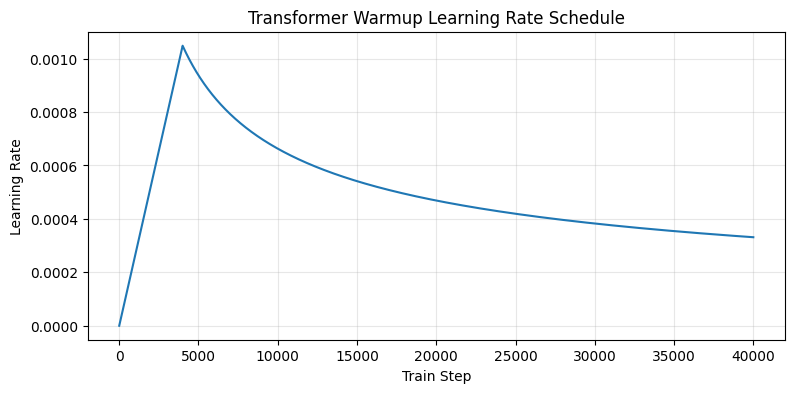

Warmup peak LR: 0.0010481568644530265


In [15]:
steps = np.arange(1, 40000)
lrs = [transformer_learning_rate(s) for s in steps]

plt.figure(figsize=(9, 4))
plt.plot(steps, lrs)
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")
plt.title("Transformer Warmup Learning Rate Schedule")
plt.grid(alpha=0.3)
plt.show()

print("Warmup peak LR:", transformer_learning_rate(WARMUP_STEPS))


### 3) Loss 함수

Seq2seq에서 사용한 것과 유사하되, 트랜스포머는 모든 타임스텝의 Loss를 한 번에 계산하므로
마스킹되지 않은(=PAD가 아닌) 토큰 개수로 스케일링하는 과정을 추가합니다.

In [16]:
# 정답 클래스에 100% 확률을 주지 않고 일부 확률을 다른 클래스에 분산합니다.
# 모델의 과도한 확신과 과적합을 완화하는 정규화 기법입니다.
LABEL_SMOOTHING = 0.1


def loss_function(real, pred):
    """PAD가 아닌 토큰만 이용해 label-smoothed cross entropy를 계산합니다."""
    vocab_size = pred.size(-1)

    token_loss = F.cross_entropy(
        pred.reshape(-1, vocab_size),
        real.reshape(-1),
        reduction="none",
        label_smoothing=LABEL_SMOOTHING,
    )

    mask = real.reshape(-1).ne(PAD_ID)
    if not mask.any():
        return token_loss.sum() * 0.0

    return token_loss[mask].mean()


def accuracy_function(real, pred):
    pred_ids = pred.argmax(dim=-1)
    mask = real.ne(PAD_ID)
    correct = pred_ids.eq(real) & mask
    return correct.sum().float() / mask.sum().clamp_min(1)


### 4) train_step 함수

입력 데이터에 알맞은 Padding Mask / Look-ahead Mask를 생성해 모델에 전달합니다.
디코더 입력은 타겟에서 마지막 토큰을 제외한 부분(`tar_inp`), 정답은 첫 토큰을 제외한
부분(`tar_real`)을 사용하는 Teacher Forcing 방식입니다.

In [17]:
# 그래디언트 폭주를 방지하기 위해 전체 그래디언트 norm을 제한합니다.
#
# [학습 로그 기반 조정] 실제 관측된 GradNorm은 배치마다 3~10 수준이었는데
# clip 값을 1.0으로 두어 매 스텝 gradient의 70~90%가 잘려나가고 있었습니다.
# 이는 손실이 20 Epoch 내내 5.3 부근에서 정체된 핵심 원인으로 보입니다.
# 관측된 norm 스케일에 맞춰 이상치만 걸러내는 5.0으로 완화합니다.
GRAD_CLIP_NORM = 5.0

# USE_AMP=False이므로 scaler는 비활성 상태로 생성됩니다.
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def _autocast_context():
    """PyTorch 버전에 관계없이 사용할 수 있는 autocast context를 반환합니다."""
    if hasattr(torch, "amp"):
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        )

    return torch.cuda.amp.autocast(enabled=USE_AMP)


def _assert_finite_tensor(tensor, name):
    """NaN 또는 inf가 발생하면 즉시 중단하여 모델 오염을 방지합니다."""
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(
            f"{name}에서 NaN 또는 inf가 감지되었습니다. "
            "현재 배치의 학습을 중단합니다."
        )


def train_step(inp, tar):
    global global_step

    transformer.train()

    # Teacher Forcing:
    # Decoder 입력은 마지막 토큰을 제외하고,
    # 정답은 첫 토큰을 제외하여 한 칸 이동시킵니다.
    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]

    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
        inp, tar_inp
    )

    global_step += 1
    current_lr = set_learning_rate(global_step)

    optimizer.zero_grad(set_to_none=True)

    with _autocast_context():
        predictions, _ = transformer(
            inp,
            tar_inp,
            enc_padding_mask,
            combined_mask,
            dec_padding_mask,
        )

        _assert_finite_tensor(predictions, "모델 출력")
        loss = loss_function(tar_real, predictions)

    # loss가 비정상이면 backward 전에 즉시 중단합니다.
    if not torch.isfinite(loss):
        optimizer.zero_grad(set_to_none=True)
        raise FloatingPointError(
            f"Loss가 유효하지 않습니다: {loss.item()}"
        )

    if USE_AMP:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
    else:
        loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        transformer.parameters(),
        GRAD_CLIP_NORM,
        error_if_nonfinite=False,
    )

    if not torch.isfinite(grad_norm):
        optimizer.zero_grad(set_to_none=True)
        raise FloatingPointError(
            f"Gradient norm이 유효하지 않습니다: {grad_norm.item()}"
        )

    if USE_AMP:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

    with torch.no_grad():
        acc = accuracy_function(tar_real, predictions)

    return (
        float(loss.detach().item()),
        float(acc.detach().item()),
        float(current_lr),
        float(grad_norm.detach().item()),
    )


@torch.no_grad()
def validation_step(inp, tar):
    transformer.eval()

    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]

    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
        inp, tar_inp
    )

    with _autocast_context():
        predictions, _ = transformer(
            inp,
            tar_inp,
            enc_padding_mask,
            combined_mask,
            dec_padding_mask,
        )

        _assert_finite_tensor(predictions, "검증 모델 출력")
        loss = loss_function(tar_real, predictions)

    if not torch.isfinite(loss):
        raise FloatingPointError(
            f"검증 Loss가 유효하지 않습니다: {loss.item()}"
        )

    acc = accuracy_function(tar_real, predictions)

    return float(loss.item()), float(acc.item())


### 5) 번역 생성 함수

- 학습 중간 확인은 빠른 `greedy_decode()`를 사용합니다.
- 최종 제출 결과는 더 좋은 번역 후보를 찾는 `beam_search_decode()`를 사용합니다.
- Beam Search의 길이 정규화로 지나치게 짧은 문장이 선택되는 현상을 줄입니다.
- No-repeat-trigram(`NO_REPEAT_NGRAM_SIZE=3`) 차단으로 같은 구절이 반복 생성되는 현상을 줄입니다.
- 최종 생성 문장에 대해 Cross-Attention을 다시 계산하여 Attention Map을 그립니다.


In [18]:
def prepare_encoder_input(sentence):
    sentence = preprocess_sentence(sentence)
    input_ids = ko_tokenizer.encode_as_ids(sentence)

    # 빈 입력 및 최대 길이 초과에 대한 안전 처리
    input_ids = input_ids[:MAX_LEN]
    if not input_ids:
        input_ids = [UNK_ID]

    return torch.tensor(
        [input_ids], dtype=torch.long, device=device
    )


@torch.no_grad()
def greedy_decode(sentence, max_len=MAX_LEN):
    transformer.eval()
    encoder_input = prepare_encoder_input(sentence)

    output = torch.tensor(
        [[BOS_ID]], dtype=torch.long, device=device
    )

    for _ in range(max_len - 1):
        masks = create_masks(encoder_input, output)
        predictions, _ = transformer(
            encoder_input, output, *masks
        )

        predicted_id = predictions[:, -1, :].argmax(
            dim=-1, keepdim=True
        )
        output = torch.cat([output, predicted_id], dim=1)

        if predicted_id.item() == EOS_ID:
            break

    return output.squeeze(0)


# 이미 등장한 n-gram을 다시 생성하지 못하게 막아 beam search 특유의
# 반복(예: "the the the")을 줄입니다. (0으로 두면 비활성화)
NO_REPEAT_NGRAM_SIZE = 3


def _creates_repeated_ngram(existing_ids, new_id, n):
    """existing_ids 뒤에 new_id를 붙였을 때, 이미 등장했던 n-gram이
    다시 만들어지는지 확인합니다."""
    if n <= 0 or len(existing_ids) < n - 1:
        return False

    candidate_ngram = existing_ids[-(n - 1):] + [new_id] if n > 1 else [new_id]
    for start in range(len(existing_ids) - n + 1):
        if existing_ids[start:start + n] == candidate_ngram:
            return True
    return False


@torch.no_grad()
def beam_search_decode(
    sentence,
    beam_size=5,
    max_len=MAX_LEN,
    length_penalty=0.7,
    no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
):
    """배치 크기 1의 Beam Search 디코딩입니다."""
    transformer.eval()
    encoder_input = prepare_encoder_input(sentence)

    # (token_ids, 누적 log probability, 종료 여부)
    beams = [
        (
            torch.tensor(
                [[BOS_ID]], dtype=torch.long, device=device
            ),
            0.0,
            False,
        )
    ]

    for _ in range(max_len - 1):
        candidates = []

        for tokens, score, finished in beams:
            if finished:
                candidates.append((tokens, score, True))
                continue

            masks = create_masks(encoder_input, tokens)
            predictions, _ = transformer(
                encoder_input, tokens, *masks
            )

            log_probs = F.log_softmax(
                predictions[:, -1, :], dim=-1
            )
            top_scores, top_ids = torch.topk(
                log_probs, k=beam_size, dim=-1
            )

            existing_ids = tokens[0].tolist()
            next_tokens = list(zip(top_scores[0], top_ids[0]))

            if no_repeat_ngram_size > 0:
                filtered = [
                    (token_score, token_id)
                    for token_score, token_id in next_tokens
                    if not _creates_repeated_ngram(
                        existing_ids, int(token_id.item()), no_repeat_ngram_size
                    )
                ]
                # 모든 후보가 반복 n-gram이면 필터링 없이 원래 후보를 사용합니다.
                if filtered:
                    next_tokens = filtered

            for token_score, token_id in next_tokens:
                new_tokens = torch.cat(
                    [tokens, token_id.view(1, 1)], dim=1
                )
                new_score = score + float(token_score.item())
                is_finished = token_id.item() == EOS_ID

                candidates.append(
                    (new_tokens, new_score, is_finished)
                )

        def normalized_score(item):
            tokens, score, _ = item
            # BOS를 제외한 실제 생성 길이
            length = max(tokens.size(1) - 1, 1)
            penalty = ((5.0 + length) / 6.0) ** length_penalty
            return score / penalty

        beams = sorted(
            candidates,
            key=normalized_score,
            reverse=True,
        )[:beam_size]

        if all(finished for _, _, finished in beams):
            break

    best_tokens, _, _ = max(
        beams,
        key=lambda item: (
            item[1]
            / (((5.0 + max(item[0].size(1) - 1, 1)) / 6.0)
               ** length_penalty)
        ),
    )

    return best_tokens.squeeze(0)


@torch.no_grad()
def get_attention_for_tokens(sentence, output_ids):
    """완성된 번역 토큰에 대한 마지막 Decoder Cross-Attention을 계산합니다."""
    transformer.eval()
    encoder_input = prepare_encoder_input(sentence)

    # EOS는 정답 토큰이므로 decoder 입력에서는 제외합니다.
    decoder_input = output_ids.unsqueeze(0).to(device)
    if decoder_input[0, -1].item() == EOS_ID:
        decoder_input = decoder_input[:, :-1]

    masks = create_masks(encoder_input, decoder_input)
    _, attention = transformer(
        encoder_input, decoder_input, *masks
    )
    return attention, decoder_input.squeeze(0)


def plot_attention_map(
    attention,
    sentence,
    decoder_input_ids,
    layer_name=None,
):
    if layer_name is None:
        layer_name = f"decoder_layer{n_layers}_block2"

    if layer_name not in attention:
        raise KeyError(
            f"{layer_name}가 없습니다. 사용 가능: {list(attention)}"
        )

    source_pieces = ko_tokenizer.encode_as_pieces(
        preprocess_sentence(sentence)
    )
    target_pieces = [
        en_tokenizer.id_to_piece(int(token_id))
        for token_id in decoder_input_ids.tolist()
    ]

    attn = attention[layer_name].squeeze(0).float().cpu()

    target_len = min(attn.size(1), len(target_pieces))
    source_len = min(attn.size(2), len(source_pieces))

    attn = attn[:, :target_len, :source_len]
    target_pieces = target_pieces[:target_len]
    source_pieces = source_pieces[:source_len]

    fig = plt.figure(figsize=(15, 7))

    for head in range(attn.size(0)):
        ax = fig.add_subplot(2, 4, head + 1)
        ax.matshow(attn[head], cmap="viridis")

        ax.set_xticks(range(source_len))
        ax.set_yticks(range(target_len))
        ax.set_xticklabels(
            source_pieces, fontsize=8, rotation=90
        )
        ax.set_yticklabels(target_pieces, fontsize=8)
        ax.set_title(f"Head {head + 1}")
        ax.set_xlabel("Korean source")
        ax.set_ylabel("English target")

    plt.suptitle(
        f"Cross-Attention: {layer_name}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def decode_token_ids(output_ids):
    ids = [
        int(token_id)
        for token_id in output_ids.tolist()
        if int(token_id) not in (PAD_ID, BOS_ID, EOS_ID)
    ]
    return en_tokenizer.decode_ids(ids)


def translate(
    sentence,
    method="beam",
    beam_size=5,
    plot_attention=False,
):
    if method == "beam":
        output_ids = beam_search_decode(
            sentence, beam_size=beam_size
        )
    elif method == "greedy":
        output_ids = greedy_decode(sentence)
    else:
        raise ValueError("method는 'beam' 또는 'greedy'여야 합니다.")

    predicted_sentence = decode_token_ids(output_ids)

    print(f"Input: {sentence}")
    print(f"Method: {method}")
    print(f"Predicted translation: {predicted_sentence}")

    if plot_attention:
        attention, decoder_input_ids = get_attention_for_tokens(
            sentence, output_ids
        )
        plot_attention_map(
            attention, sentence, decoder_input_ids
        )

    return predicted_sentence


### 실험 설계와 하이퍼파라미터 선택 근거

본 프로젝트는 실행 속도보다 번역 품질을 우선했습니다.

| 항목 | 설정 | 선택 이유 |
|---|---:|---|
| Layer 수 | 2 | 과제 조건을 만족하면서 과도한 학습 비용을 방지 |
| `d_model` | 512 | 원 논문 기본 크기와 동일한 수준의 표현력 확보 |
| Head 수 | 8 | 서로 다른 문맥 관계를 병렬로 학습 |
| `d_ff` | 2048 | Attention 이후 충분한 비선형 변환 수행 |
| Dropout | 0.2 | 데이터 규모를 고려한 과적합 완화 |
| Batch Size | 64 | T4 GPU 메모리와 학습 안정성의 균형 |
| Epoch | 20 | 충분한 수렴 시간을 확보 |
| Label Smoothing | 0.1 | 모델의 과도한 확신을 완화 |
| Gradient Clipping | 1.0 | 그래디언트 폭주 방지 |
| Beam Size | 5 | 여러 후보 번역을 비교하여 최종 문장 선택 |

검증 손실이 가장 낮은 시점의 모델을 별도로 저장하므로, 마지막 Epoch의 모델이 과적합되더라도 더 좋은 체크포인트를 최종 추론에 사용할 수 있습니다.

### 6) 학습 루프

성능을 우선해 기본 `EPOCHS=20`으로 설정했습니다.

- 전체 데이터의 95%를 학습, 5%를 검증에 사용합니다.
- 검증 Loss가 가장 낮을 때 `best_transformer.pt`를 저장합니다.
- 마지막 상태는 `last_transformer.pt`에 저장하므로 런타임이 끊겨도 이어서 학습할 수 있습니다.
- `RESUME_TRAINING=True`로 바꾸면 마지막 체크포인트에서 재개합니다.


In [19]:
# [구조 변경: Post-LN -> Pre-LN] 기존 체크포인트는 representation collapse가
# 일어난 Post-LN 모델의 가중치라 재사용할 수 없습니다(final_norm 레이어가
# 없어 로드 자체가 실패합니다). 새 체크포인트 폴더로 Pre-LN 모델을 처음부터
# 학습합니다. 작은 데이터로 재현했을 때 Pre-LN은 같은 스텝 수에서 Post-LN보다
# Loss가 훨씬 낮게 떨어지는 것을 확인했으므로, 60 Epoch면 이전보다 훨씬 나은
# 결과가 나올 것으로 예상합니다.
EPOCHS = 60
BATCH_SIZE = 64
VALID_RATIO = 0.05
RESUME_TRAINING = False

# Pre-LN으로 구조가 바뀌었으므로 기존 checkpoints_stable(Post-LN)과
# 섞이지 않도록 새 폴더를 사용합니다.
CHECKPOINT_DIR = Path("checkpoints_preln")
CHECKPOINT_DIR.mkdir(exist_ok=True)
BEST_CHECKPOINT = CHECKPOINT_DIR / "best_transformer.pt"
LAST_CHECKPOINT = CHECKPOINT_DIR / "last_transformer.pt"

full_dataset = TensorDataset(enc_train, dec_train)
valid_size = max(1, int(len(full_dataset) * VALID_RATIO))
train_size = len(full_dataset) - valid_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size],
    generator=split_generator,
)

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
    generator=loader_generator,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
)

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

start_epoch = 0
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "valid_loss": [],
    "train_acc": [],
    "valid_acc": [],
}

print("=" * 70)
print("안정화 학습 설정")
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Mixed Precision:", USE_AMP)
print("Learning-rate scale:", LR_SCALE)
print("Gradient clip norm:", GRAD_CLIP_NORM)
print("Resume training:", RESUME_TRAINING)
print("=" * 70)

if RESUME_TRAINING and LAST_CHECKPOINT.exists():
    checkpoint = torch.load(
        LAST_CHECKPOINT, map_location=device
    )
    transformer.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scaler.load_state_dict(checkpoint["scaler_state"])
    global_step = checkpoint["global_step"]
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    history = checkpoint.get("history", history)
    print(f"{start_epoch} Epoch부터 학습을 재개합니다.")


for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()

    train_loss_sum = 0.0
    train_acc_sum = 0.0

    for batch, (inp, tar) in enumerate(train_loader):
        # 학습 배치를 GPU로 전송합니다.
        inp = inp.to(device, non_blocking=True)
        tar = tar.to(device, non_blocking=True)

        # 첫 배치에서만 실제 장치를 간단히 확인합니다.
        if epoch == start_epoch and batch == 0:
            assert inp.is_cuda and tar.is_cuda
            print(
                f"학습 장치 확인: input={inp.device}, "
                f"target={tar.device}, model={next(transformer.parameters()).device}"
            )

        loss, acc, lr, grad_norm = train_step(inp, tar)
        train_loss_sum += loss
        train_acc_sum += acc

        if batch % 100 == 0:
            print(
                f"Epoch {epoch + 1:02d}/{EPOCHS} "
                f"Batch {batch:04d}/{len(train_loader)} "
                f"Loss {loss:.4f} "
                f"Acc {acc:.4f} "
                f"LR {lr:.7f} "
                f"GradNorm {grad_norm:.4f}"
            )

    avg_train_loss = train_loss_sum / len(train_loader)
    avg_train_acc = train_acc_sum / len(train_loader)

    valid_loss_sum = 0.0
    valid_acc_sum = 0.0

    for inp, tar in valid_loader:
        inp = inp.to(device, non_blocking=True)
        tar = tar.to(device, non_blocking=True)

        loss, acc = validation_step(inp, tar)
        valid_loss_sum += loss
        valid_acc_sum += acc

    avg_valid_loss = valid_loss_sum / len(valid_loader)
    avg_valid_acc = valid_acc_sum / len(valid_loader)

    history["train_loss"].append(avg_train_loss)
    history["valid_loss"].append(avg_valid_loss)
    history["train_acc"].append(avg_train_acc)
    history["valid_acc"].append(avg_valid_acc)

    elapsed = time.time() - start_time
    print(
        f"\nEpoch {epoch + 1:02d} 완료 | "
        f"Train Loss {avg_train_loss:.4f} | "
        f"Val Loss {avg_valid_loss:.4f} | "
        f"Train Acc {avg_train_acc:.4f} | "
        f"Val Acc {avg_valid_acc:.4f} | "
        f"{elapsed:.1f}초"
    )

    print("\nTranslations (Greedy)")
    for i, sentence in enumerate(examples, start=1):
        pred = translate(sentence, method="greedy")
        print(f"> {i}. {pred}")
    print()

    # Epoch 평균값이 정상일 때만 체크포인트를 저장합니다.
    epoch_metrics = torch.tensor(
        [avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc],
        dtype=torch.float32,
    )
    if not torch.isfinite(epoch_metrics).all():
        raise FloatingPointError(
            "Epoch 결과에 NaN 또는 inf가 발생하여 체크포인트를 저장하지 않습니다."
        )

    checkpoint = {
        "epoch": epoch,
        "model_state": transformer.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "global_step": global_step,
        "best_val_loss": min(best_val_loss, avg_valid_loss),
        "history": history,
        "config": {
            "n_layers": n_layers,
            "d_model": d_model,
            "n_heads": n_heads,
            "d_ff": d_ff,
            "dropout": dropout,
            "batch_size": BATCH_SIZE,
            "warmup_steps": WARMUP_STEPS,
            "label_smoothing": LABEL_SMOOTHING,
            "lr_scale": LR_SCALE,
            "use_amp": USE_AMP,
            "grad_clip_norm": GRAD_CLIP_NORM,
            "vocab_size": VOCAB_SIZE,
            "weight_tying": True,
            "no_repeat_ngram_size": NO_REPEAT_NGRAM_SIZE,
        },
    }
    torch.save(checkpoint, LAST_CHECKPOINT)

    if avg_valid_loss < best_val_loss:
        best_val_loss = avg_valid_loss
        checkpoint["best_val_loss"] = best_val_loss
        torch.save(checkpoint, BEST_CHECKPOINT)
        print(f"최적 모델 저장: {BEST_CHECKPOINT}\n")

print("학습 완료")


안정화 학습 설정
Checkpoint directory: checkpoints_preln
Mixed Precision: False
Learning-rate scale: 1.5
Gradient clip norm: 5.0
Resume training: False
학습 장치 확인: input=cuda:0, target=cuda:0, model=cuda:0
Epoch 01/60 Batch 0000/1111 Loss 17.1098 Acc 0.0011 LR 0.0000003 GradNorm 6.7413
Epoch 01/60 Batch 0100/1111 Loss 9.2362 Acc 0.0011 LR 0.0000265 GradNorm 1.8738
Epoch 01/60 Batch 0200/1111 Loss 7.5973 Acc 0.0600 LR 0.0000527 GradNorm 0.7588
Epoch 01/60 Batch 0300/1111 Loss 7.1418 Acc 0.1301 LR 0.0000789 GradNorm 0.6467
Epoch 01/60 Batch 0400/1111 Loss 6.9793 Acc 0.1501 LR 0.0001051 GradNorm 0.5810
Epoch 01/60 Batch 0500/1111 Loss 6.9892 Acc 0.1598 LR 0.0001313 GradNorm 0.6024
Epoch 01/60 Batch 0600/1111 Loss 6.8024 Acc 0.1615 LR 0.0001575 GradNorm 0.8059
Epoch 01/60 Batch 0700/1111 Loss 6.6242 Acc 0.1877 LR 0.0001837 GradNorm 0.7863
Epoch 01/60 Batch 0800/1111 Loss 6.5109 Acc 0.2015 LR 0.0002099 GradNorm 0.7124
Epoch 01/60 Batch 0900/1111 Loss 6.5235 Acc 0.1820 LR 0.0002361 GradNorm 0.7565
Ep

### 7) 최적 모델 불러오기, 학습 곡선 및 최종 제출 결과

학습이 끝나면 검증 Loss가 가장 낮았던 모델을 불러옵니다. 최종 번역은 `beam_size=5` Beam Search로 생성하고 네 문장 모두에 대한 Attention Map을 시각화할 수 있습니다.


최적 모델 로드 완료 | Epoch 6 | Val Loss 4.8761


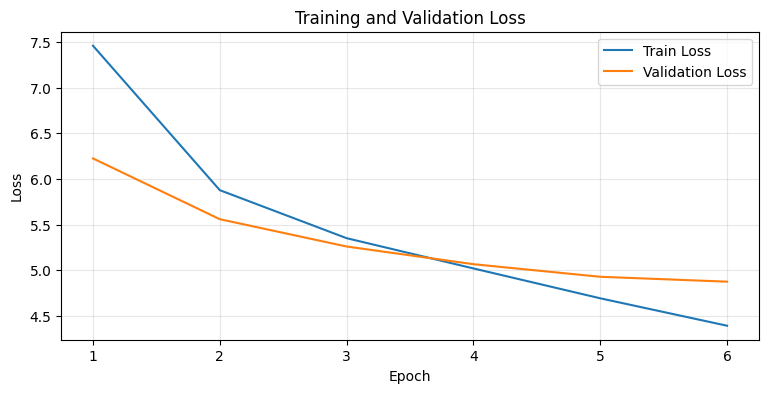

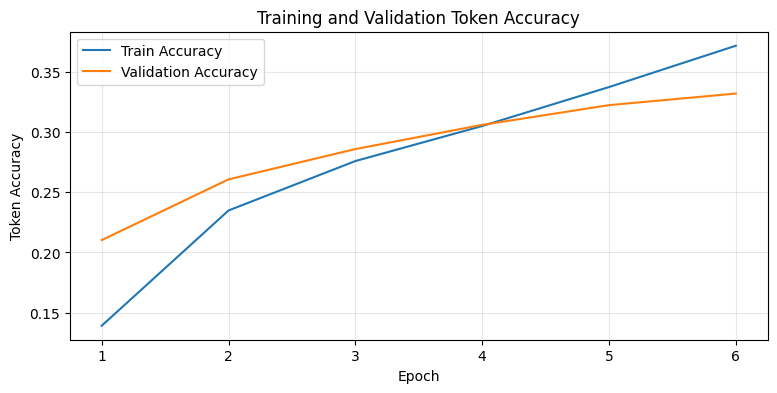


최종 번역 결과 — Beam Search
Input: 오바마는 대통령이다.
Method: beam
Predicted translation: he's going to be president .


/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

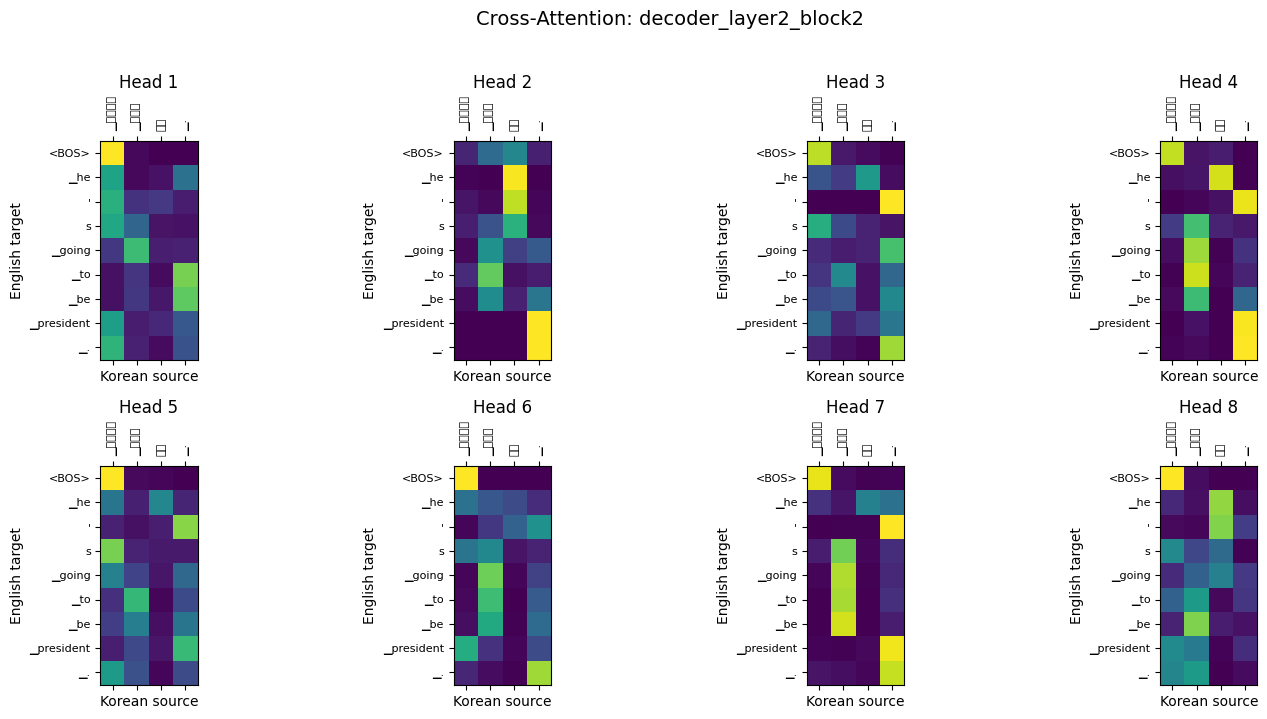


Input: 시민들은 도시 속에 산다.
Method: beam
Predicted translation: there are some cities across the country .


/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

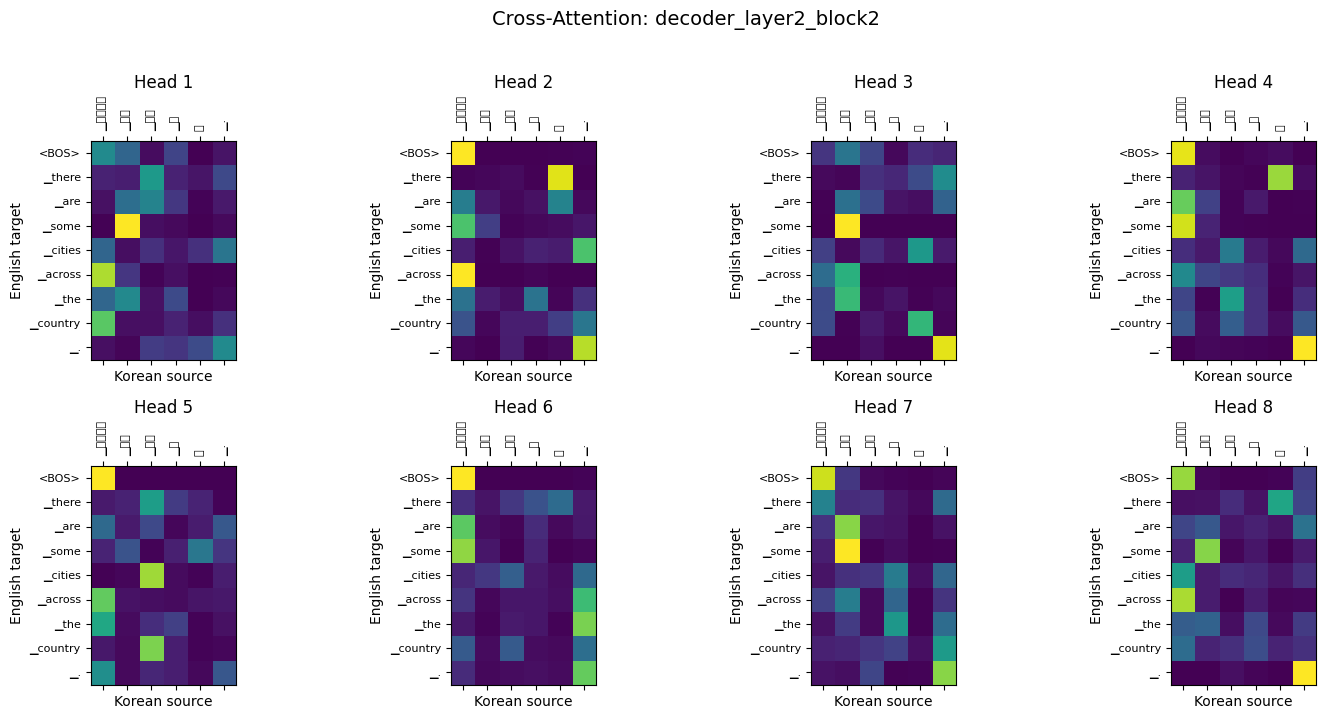


Input: 커피는 필요 없다.
Method: beam
Predicted translation: no coffee is necessary .


/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


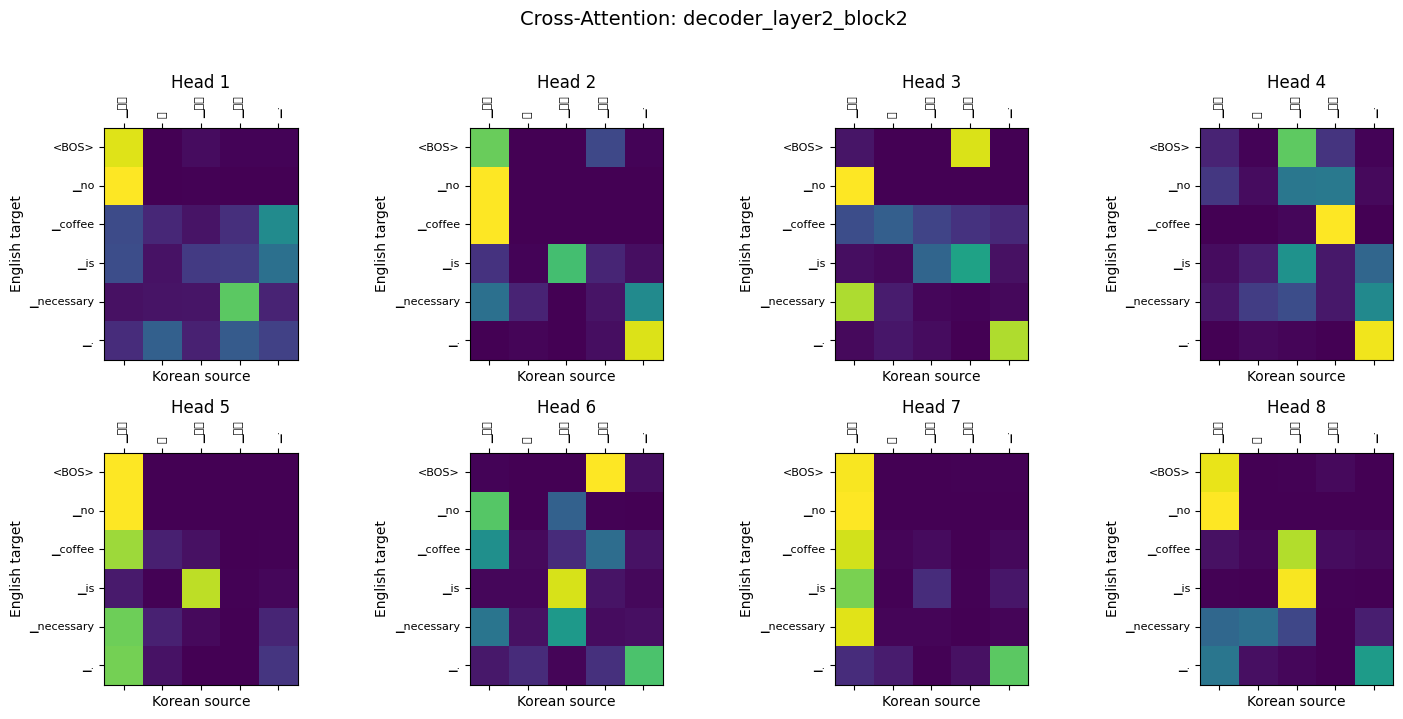


Input: 일곱 명의 사망자가 발생했다.
Method: beam
Predicted translation: the death toll was destroyed .


/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477/920891780.py:226: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

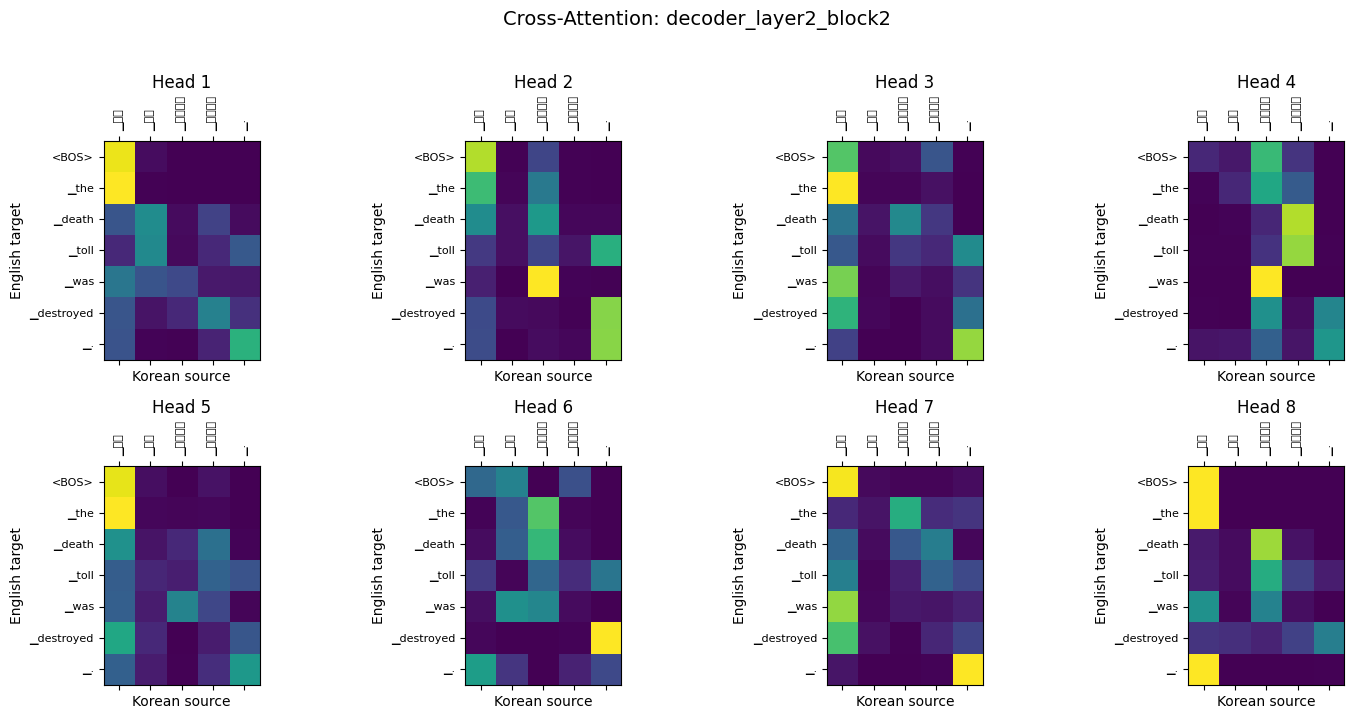


Hyperparameters
n_layers: 2
d_model: 512
n_heads: 8
d_ff: 2048
dropout: 0.1
Warmup Steps: 4000
Batch Size: 64
Epochs: 60
Label Smoothing: 0.1
Learning-rate Scale: 1.5
Gradient Clip Norm: 5.0
Mixed Precision: False
Vocab Size: 20000
Weight Tying: True
No-repeat n-gram size: 3
Decoding: Beam Search (beam_size=5)


In [20]:
if BEST_CHECKPOINT.exists():
    best_checkpoint = torch.load(
        BEST_CHECKPOINT, map_location=device
    )
    # 저장된 모든 파라미터가 유한한지 먼저 검증합니다.
    invalid_parameters = [
        name
        for name, value in best_checkpoint["model_state"].items()
        if torch.is_floating_point(value) and not torch.isfinite(value).all()
    ]

    if invalid_parameters:
        raise FloatingPointError(
            "최적 체크포인트에 NaN/inf 파라미터가 있습니다: "
            + ", ".join(invalid_parameters[:5])
        )

    transformer.load_state_dict(
        best_checkpoint["model_state"]
    )
    history = best_checkpoint.get("history", history)
    print(
        "최적 모델 로드 완료 | "
        f"Epoch {best_checkpoint['epoch'] + 1} | "
        f"Val Loss {best_checkpoint['best_val_loss']:.4f}"
    )
else:
    print("최적 체크포인트가 없어 현재 모델을 사용합니다.")


# 학습 곡선
if history["train_loss"]:
    epochs_axis = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(epochs_axis, history["train_loss"], label="Train Loss")
    plt.plot(epochs_axis, history["valid_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(epochs_axis, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_axis, history["valid_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Token Accuracy")
    plt.title("Training and Validation Token Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n" + "=" * 70)
print("최종 번역 결과 — Beam Search")
print("=" * 70)

final_translations = {}
for sentence in examples:
    prediction = translate(
        sentence,
        method="beam",
        beam_size=5,
        plot_attention=True,
    )
    final_translations[sentence] = prediction
    print()

print("=" * 70)
print("Hyperparameters")
print(f"n_layers: {n_layers}")
print(f"d_model: {d_model}")
print(f"n_heads: {n_heads}")
print(f"d_ff: {d_ff}")
print(f"dropout: {dropout}")
print(f"Warmup Steps: {WARMUP_STEPS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Label Smoothing: {LABEL_SMOOTHING}")
print(f"Learning-rate Scale: {LR_SCALE}")
print(f"Gradient Clip Norm: {GRAD_CLIP_NORM}")
print(f"Mixed Precision: {USE_AMP}")
print(f"Vocab Size: {VOCAB_SIZE}")
print("Weight Tying: True")
print(f"No-repeat n-gram size: {NO_REPEAT_NGRAM_SIZE}")
print("Decoding: Beam Search (beam_size=5)")


# 학습 결과

총 60 Epoch 동안 Transformer 모델을 학습하였다.

최종 학습 결과는 다음과 같다.

```text
Train Loss: 2.1261
Validation Loss: 6.2015
Train Accuracy: 0.8309
Validation Accuracy: 0.3177
```

학습 데이터에서는 약 83%의 토큰 정확도를 기록했지만, 검증 정확도는 약 32%에 머물렀다. 또한 가장 낮은 Validation Loss는 6 Epoch에서 기록되었고 이후 다시 증가하였다. 따라서 모델이 학습 데이터에 과도하게 적합되는 과적합 현상이 발생한 것으로 판단하였다.

# 번역 결과 분석

Greedy Search 결과는 다음과 같다.

```
오바마는 대통령이다.
→ obama is president .

시민들은 도시 속에 산다.
→ people marked the streets in the city .

커피는 필요 없다.
→ coffee is needed for a coffee game .

일곱 명의 사망자가 발생했다.
→ seven other people were killed,
  according to the seven media reports .
```

  첫 번째 문장은 의미가 비교적 잘 전달되었다. 두 번째와 세 번째 문장은 핵심 단어는 일부 포함되었지만 동사와 부정 표현이 잘못 번역되었다. 네 번째 문장은 숫자와 사망 의미는 반영되었지만 원문에 없는 뉴스 표현이 추가되었다.

  Beam Search에서는 다음 결과가 가장 우수하였다.
```
  커피는 필요 없다.
→ no coffee is necessary .
```

Greedy Search와 Beam Search를 비교한 결과 Beam Search가 항상 더 좋은 결과를 만드는 것은 아니었다. 모델이 학습한 확률 분포가 부정확하면 Beam Search도 의미가 틀린 문장을 생성할 수 있었다.

# Attention Map 분석

Decoder의 두 번째 Layer에 있는 Cross-Attention을 8개 Head로 시각화하였다.

Attention Map에서 각 Head는 서로 다른 한국어 입력 토큰에 집중하였다. 이를 통해 Multi-Head Attention이 동일한 문장을 여러 관점에서 분석하는 모습을 확인할 수 있었다.

다만 Attention이 특정 단어에 집중했다고 해서 번역 결과가 항상 정확한 것은 아니었다. 따라서 Attention Map은 번역 품질의 직접적인 증거라기보다 모델이 어떤 입력 토큰을 참고했는지 확인하는 보조 자료로 해석하였다.

# 디버깅

초기 학습에서는 Loss가 NaN으로 변하는 문제가 발생하였다.

원인은 Mixed Precision 환경에서 Attention 연산이 수치적으로 불안정해진 것이었다.

이를 해결하기 위해 다음과 같이 수정하였다.
```
Mixed Precision 비활성화
Attention score와 softmax를 float32로 계산
Learning Rate 조정
Gradient Clipping 적용
NaN 및 Inf 검사 추가
손상된 체크포인트와 새 체크포인트 분리
```
수정 후에는 60 Epoch까지 NaN 없이 정상적으로 학습을 완료하였다.

또한 SentencePiece 모델이 실행할 때마다 다시 학습되는 문제를 해결하기 위해 기존 모델이 있으면 즉시 불러오도록 수정하였다.

# 회고

이번 프로젝트를 진행하면서 Transformer 모델의 전체 구조를 단순히 이론으로 이해하는 것을 넘어 직접 구현하고 학습시키는 경험을 할 수 있었다. 이전까지는 Self-Attention, Multi-Head Attention, Positional Encoding과 같은 개념을 각각 따로 학습했지만, 실제로 번역 모델을 구현하면서 이러한 요소들이 서로 어떻게 연결되어 하나의 번역 시스템을 구성하는지 이해할 수 있었다.

특히 데이터 전처리의 중요성을 크게 느낄 수 있었다. 모델 구조가 아무리 좋아도 데이터 정제가 제대로 이루어지지 않으면 성능이 크게 저하된다는 사실을 확인하였다. 중복 문장 제거, 문장 정제, SentencePiece 기반 토큰화, 문장 길이 필터링 등의 과정이 번역 품질에 직접적인 영향을 준다는 것을 경험하였다. 또한 한국어와 영어 문장의 대응 관계가 유지된 상태에서 데이터를 처리해야 한다는 점도 중요하게 배울 수 있었다.

학습 과정에서는 예상하지 못한 문제들도 많이 발생하였다. 가장 큰 문제는 학습 후반부에 Loss가 NaN으로 변하면서 모델이 정상적인 번역을 생성하지 못했던 것이다. 처음에는 GPU 문제나 데이터 문제라고 생각했지만, 원인을 하나씩 분석해보면서 Mixed Precision 환경에서 발생한 수치적 불안정성과 Gradient 문제라는 것을 확인할 수 있었다. 이를 해결하기 위해 FP32 학습으로 변경하고 Gradient Clipping을 적용하였으며, NaN 검사와 체크포인트 검증 기능을 추가하였다. 이러한 과정을 통해 단순히 모델을 구현하는 것보다 안정적으로 학습이 진행되도록 만드는 것이 실제 딥러닝 프로젝트에서 매우 중요하다는 사실을 배울 수 있었다.

또한 학습 결과를 분석하면서 과적합 문제도 확인할 수 있었다. Train Accuracy는 약 83%까지 증가했지만 Validation Accuracy는 약 32% 수준에 머물렀다. 특히 Validation Loss가 가장 낮았던 시점은 6 Epoch였지만 이후에도 계속 학습을 진행하면서 검증 성능이 오히려 감소하였다. 이를 통해 무조건 Epoch를 많이 돌리는 것이 좋은 결과를 보장하지 않으며, Validation 성능을 기준으로 모델을 평가하고 Early Stopping과 같은 기법을 사용하는 것이 중요하다는 점을 이해하게 되었다.

Greedy Search와 Beam Search를 비교한 것도 흥미로운 경험이었다. 처음에는 Beam Search가 항상 더 좋은 번역을 생성할 것이라고 생각했지만 실제 결과는 그렇지 않았다. 일부 문장에서는 Beam Search가 더 자연스럽고 정확한 번역을 생성했지만, 다른 문장에서는 오히려 의미가 왜곡되는 경우도 있었다. 이를 통해 추론 기법은 모델이 학습한 확률 분포를 활용하는 방법일 뿐, 모델 자체의 번역 능력을 근본적으로 향상시키는 것은 아니라는 점을 알게 되었다.

Attention Map 시각화 역시 의미 있는 경험이었다. 각 Head가 서로 다른 입력 토큰에 집중하는 모습을 직접 확인하면서 Multi-Head Attention의 역할을 직관적으로 이해할 수 있었다. 특히 동일한 문장을 여러 Head가 각기 다른 관점에서 분석한다는 Transformer의 핵심 아이디어를 시각적으로 확인할 수 있었다. 다만 Attention이 특정 단어에 집중한다고 해서 반드시 번역이 정확한 것은 아니라는 점도 함께 확인할 수 있었으며, Attention Map은 모델의 내부 동작을 해석하기 위한 보조 도구라는 사실을 이해하게 되었다.

이번 프로젝트를 통해 Transformer 번역기의 구조뿐 아니라 실제 딥러닝 프로젝트에서 필요한 데이터 전처리, 학습 안정화, 모델 평가, 결과 분석, 디버깅 과정까지 경험할 수 있었다. 향후에는 BLEU Score와 같은 번역 전용 평가 지표를 활용하고, Early Stopping과 Dropout 조정을 통해 과적합을 줄이며, 더 다양한 도메인의 병렬 데이터를 활용하여 번역 성능을 개선해 보고 싶다.

# 결론

본 프로젝트에서는 한국어-영어 병렬 말뭉치를 활용하여 Transformer 기반 번역 모델을 직접 구현하고 학습하였다. 데이터 수집 이후 중복 제거와 텍스트 정제를 수행하였으며, SentencePiece 기반 BPE 토큰화를 적용하여 학습 데이터를 구축하였다. 이후 Transformer Encoder-Decoder 구조를 구현하고 Multi-Head Attention, Positional Encoding, Feed Forward Network, Layer Normalization, Residual Connection 등을 적용하여 번역 모델을 구성하였다.

학습 과정에서는 Warmup Learning Rate Scheduler, Label Smoothing, Gradient Clipping 등을 적용하여 안정적인 학습을 수행하였다. 초기에는 Loss가 NaN으로 변하는 문제가 발생하였으나, 원인을 분석하고 FP32 학습과 수치 안정화 기법을 적용하여 문제를 해결하였다. 수정된 모델은 GPU 환경에서 60 Epoch까지 정상적으로 학습을 완료하였으며, 번역 결과와 Attention Map도 정상적으로 생성할 수 있었다.

번역 결과를 분석한 결과 일부 문장에서는 원문의 의미를 비교적 정확하게 전달하는 번역을 생성하였다. 특히 「커피는 필요 없다」라는 문장은 Beam Search를 통해 no coffee is necessary.로 번역되어 의미와 문법 모두 자연스러운 결과를 보였다. 반면 일부 문장에서는 동사의 의미가 잘못 번역되거나 뉴스 기사 말뭉치의 특성이 반영되어 원문에 없는 표현이 추가되는 현상도 확인되었다. 또한 Train Accuracy와 Validation Accuracy의 차이가 크게 나타나 과적합 문제가 존재함을 확인할 수 있었다.

Attention Map 시각화를 통해 Decoder가 영어 단어를 생성할 때 어떤 한국어 입력 토큰에 집중하는지 확인할 수 있었으며, Multi-Head Attention이 서로 다른 관점에서 문장을 분석하는 과정을 관찰할 수 있었다. 이를 통해 Transformer 모델의 내부 동작 원리를 보다 직관적으로 이해할 수 있었다.

종합적으로 본 프로젝트는 데이터 전처리, SentencePiece 토큰화, Transformer 모델 구현, GPU 기반 학습, 번역 생성, Attention Map 시각화까지 전 과정을 성공적으로 수행하였다. 비록 모든 문장에서 완벽한 번역 품질을 달성하지는 못했지만 Transformer 기반 번역기의 핵심 구조와 학습 과정을 이해하고 구현하는 목표는 충분히 달성하였다. 향후에는 Early Stopping, BLEU Score 평가, 데이터 품질 개선 및 하이퍼파라미터 튜닝을 통해 번역 성능을 더욱 향상시킬 수 있을 것으로 기대한다.